In [1]:
# STEP 2: Mount Kaggle to download dataset
from google.colab import files
files.upload()  # ⬆️ Upload your kaggle.json file here

# Move API key to correct location
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection
!unzip -q vehide-dataset-automatic-vehicle-damage-detection.zip -d vehide_data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection
License(s): apache-2.0


In [4]:
import os
import json
import torch
import random
import numpy as np
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
import matplotlib.patches as patches
from torchvision import transforms, models
# from torchvision.references.detection import engine
# from engine import train_one_epoch, evaluate
from torchvision.datasets import CocoDetection
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import FasterRCNN
from torchvision.transforms import v2 as transforms
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [5]:
# Convert Polygon to Yolo annotations directly::

# Define class mapping (0-based index for YOLO)
CLASSES = {
    'mat_bo_phan': 0,
    'rach': 1,
    'mop_lom': 2,
    'tray_son': 3,
    'thung': 4,
    'vo_kinh': 5,
    'be_den': 6
}

def clip(x):
    return max(0, min(1, round(x, 6)))  # keeps x in range [0, 1] with 6-digit precision

def convert_and_save_annotations(image_dir, annotation_json, output_label_dir):
    # Ensure output directory exists
    os.makedirs(output_label_dir, exist_ok=True)

    with open(annotation_json) as f:
        annotations = json.load(f)

    for img_name, img_data in annotations.items():
        img_path = os.path.join(image_dir, img_name)
        label_path = os.path.join(output_label_dir, os.path.splitext(img_name)[0] + '.txt')

        # Skip if image doesn't exist
        if not os.path.exists(img_path):
            continue

        try:
            with Image.open(img_path) as img:
                img_w, img_h = img.size
        except:
            continue  # Skip corrupted images

        lines = []

        for region in img_data.get("regions", []):
            all_x = region["all_x"]
            all_y = region["all_y"]
            class_name = region["class"]

            if class_name not in CLASSES:
                continue

            # Bounding box from polygon
            x_min = min(all_x)
            y_min = min(all_y)
            w = max(all_x) - x_min
            h = max(all_y) - y_min

            x_center = clip((x_min + w / 2) / img_w)
            y_center = clip((y_min + h / 2) / img_h)
            w_norm   = clip(w / img_w)
            h_norm   = clip(h / img_h)

            class_id = CLASSES[class_name]
            lines.append(f"{class_id} {x_center} {y_center} {w_norm} {h_norm}")

        # Save annotations only if there’s at least one valid region
        if lines:
            with open(label_path, "w") as f:
                f.write("\n".join(lines))

    print(f"Saved annotations to: {output_label_dir}")

# ==== Apply for both train and val ====

# Train
convert_and_save_annotations(
    image_dir='/content/vehide_data/image/image',
    annotation_json='/content/vehide_data/0Train_via_annos.json',
    output_label_dir='/content/yolo_dataset/labels/train'
)

# Val
convert_and_save_annotations(
    image_dir='/content/vehide_data/validation/validation',
    annotation_json='/content/vehide_data/0Val_via_annos.json',
    output_label_dir='/content/yolo_dataset/labels/validation'
)

Saved annotations to: /content/yolo_dataset/labels/train
Saved annotations to: /content/yolo_dataset/labels/validation


In [6]:
import shutil
import os

def copy_images(src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for fname in os.listdir(src_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            shutil.copy(os.path.join(src_dir, fname), os.path.join(dst_dir, fname))

# Copy train images
copy_images(
    src_dir="/content/vehide_data/image/image",
    dst_dir="/content/yolo_dataset/images/train"
)

# Copy val images
copy_images(
    src_dir="/content/vehide_data/validation/validation",
    dst_dir="/content/yolo_dataset/images/validation"
)

In [3]:
# Visualize images

import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image

# Reverse class mapping
CLASS_NAMES = {
    0: 'mat_bo_phan',
    1: 'rach',
    2: 'mop_lom',
    3: 'tray_son',
    4: 'thung',
    5: 'vo_kinh',
    6: 'be_den'
}

def visualize_yolo_annotations(image_dir, label_dir, num_samples=3):
    image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(".jpg")]
    sampled_files = random.sample(image_files, num_samples)

    for img_name in sampled_files:
        img_path = os.path.join(image_dir, img_name)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')

        # Load image
        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        # Plot image
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.axis('off')

        # Draw boxes from YOLO label
        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                lines = f.readlines()

            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue

                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])

                # Convert from YOLO to pixel coordinates
                x = (x_center - width / 2) * img_w
                y = (y_center - height / 2) * img_h
                w = width * img_w
                h = height * img_h

                # Draw rectangle
                rect = patches.Rectangle(
                    (x, y), w, h,
                    linewidth=2,
                    edgecolor='red',
                    facecolor='none'
                )
                plt.gca().add_patch(rect)

                # Draw label
                label = CLASS_NAMES.get(class_id, str(class_id))
                plt.text(
                    x + w / 2, y - 10 if y > 20 else y + h + 15,
                    label,
                    color='white',
                    fontsize=10,
                    ha='center',
                    bbox=dict(facecolor='red', alpha=0.7)
                )

        plt.title(f"Image: {img_name}")
        plt.tight_layout()
        plt.show()


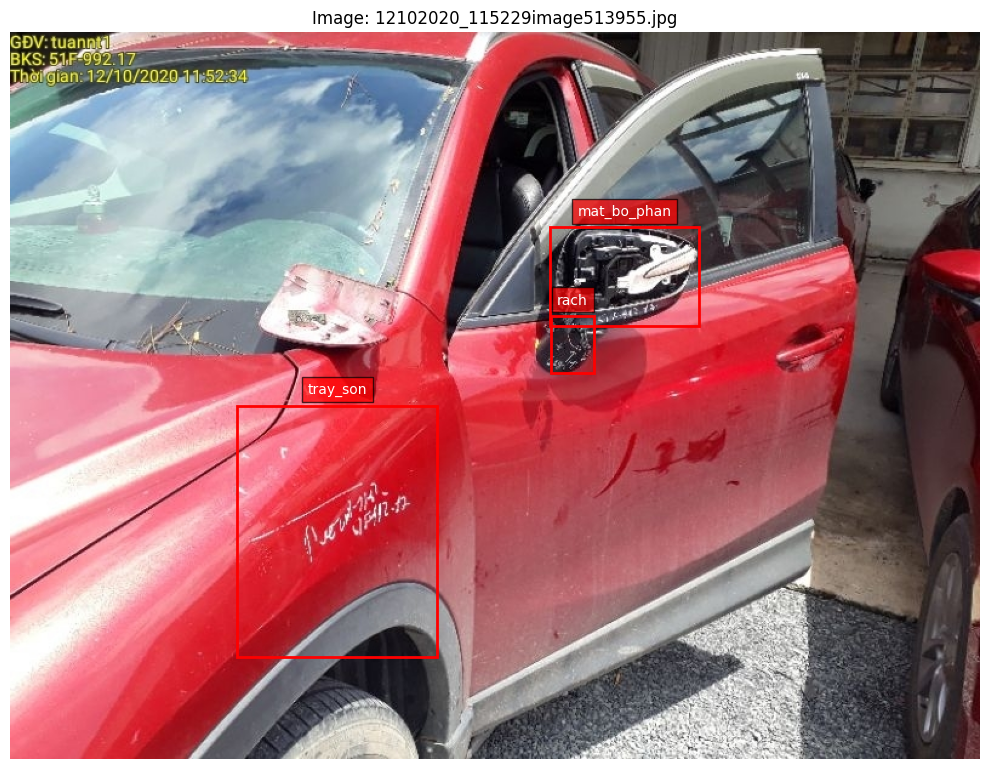

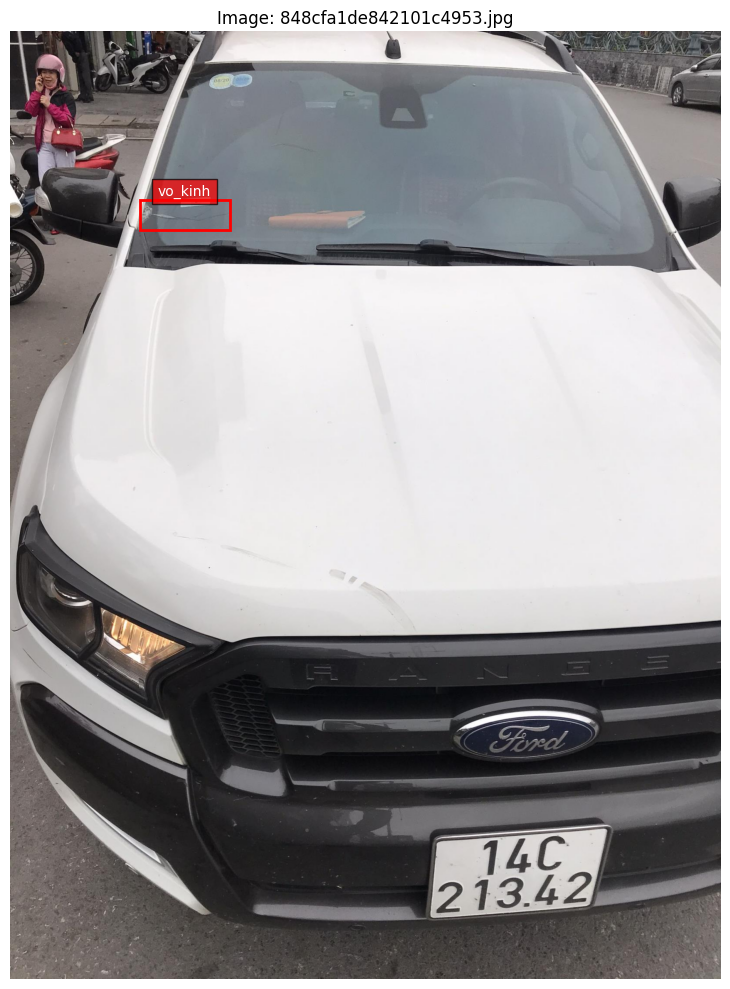

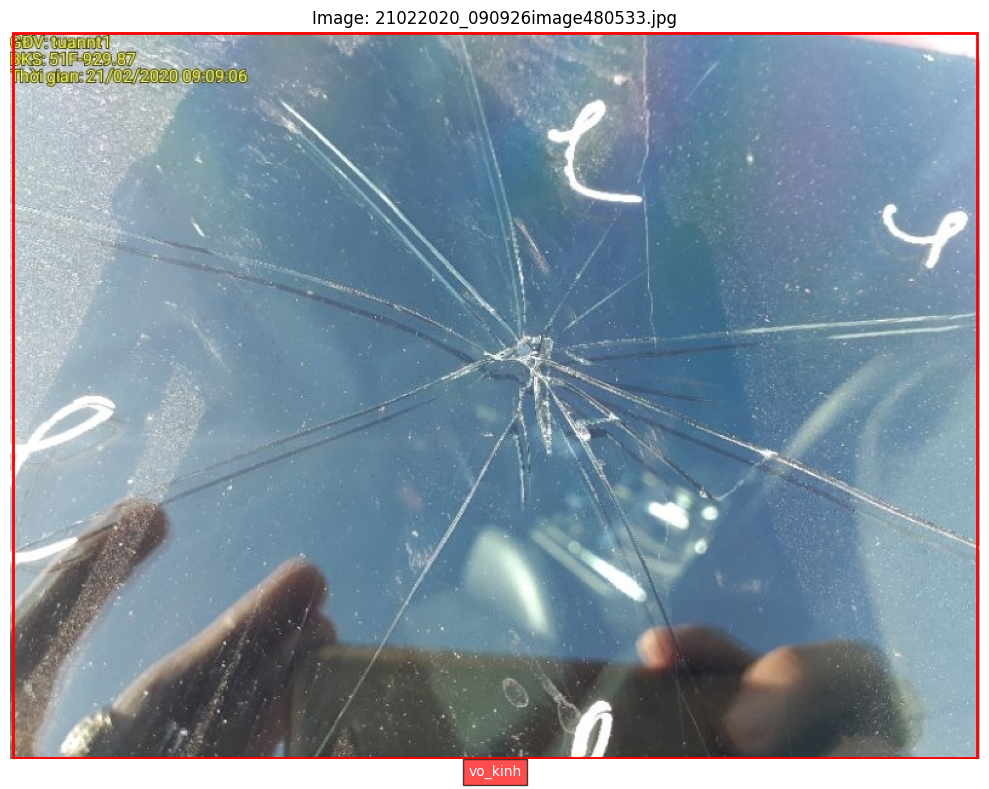

OSError: image file is truncated (83 bytes not processed)

In [4]:
# For train set
visualize_yolo_annotations(
    image_dir="/content/vehide_data/image/image",
    label_dir="/content/yolo_dataset/labels/train",
    num_samples=3
)

# For val set
visualize_yolo_annotations(
    image_dir="/content/vehide_data/validation/validation",
    label_dir="/content/yolo_dataset/labels/validation",
    num_samples=3
)

In [5]:
!pip install ultralytics pyyaml --quiet
import ultralytics
ultralytics.checks()

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.6/112.6 GB disk)


In [ ]:
from ultralytics import YOLO
import os

# Verify dataset structure
print("Dataset structure:")
!tree -d /content/yolo_dataset

# Create dataset.yaml (with 'validation' instead of 'val')
yaml_content = """
path: /content/yolo_dataset
train: images/train
validation: images/validation  # Updated to use 'validation'

names:
  0: mat_bo_phan
  1: rach
  2: mop_lom
  3: tray_son
  4: thung
  5: vo_kinh
  6: be_den

nc: 7
"""

with open('/content/dataset.yaml', 'w') as f:
    f.write(yaml_content.strip())

# Verify YAML
!cat /content/dataset.yaml

# Initialize model (choose one)
model = YOLO('yolov8n.pt')  # Nano (fastest)
# model = YOLO('yolov8s.pt')  # Small
# model = YOLO('yolov8m.pt')  # Medium
# model = YOLO('yolov8l.pt')  # Large
# model = YOLO('yolov8x.pt')  # XLarge (most accurate)

# Training parameters optimized for Kaggle
results = model.train(
    data='/content/dataset.yaml',
    epochs=100,
    batch=32,  # Reduce if OOM errors occur
    imgsz=640,
    device='0',  # Use GPU
    workers = 4,  # Kaggle limits CPU threads
    single_cls=False,
    optimizer='SGD',  # Better than SGD for small datasets
    lr0=0.005,
    cos_lr=True,  # Cosine LR scheduler
    overlap_mask=True,
    augment=True,
    patience=20,  # Early stopping
    pretrained=True,
    verbose=True,
    # amp=True,
    # Kaggle-specific optimizations
    exist_ok=True,  # Overwrite existing files
    project='/content/yolo_results',
    name='damage_detection',
    save_period=20,  # Save every 5 epochs
    # cache=True
)

# Save best model
best_model_path = '/content/best_damage_detection.pt'
model.export(format='onnx')  # Optional: Export to ONNX
!cp {results.save_dir}/weights/best.pt {best_model_path}
print(f"Best model saved to: {best_model_path}")

# Verify results
!ls -lh /content/yolo_results/damage_detection

Dataset structure:
/bin/bash: line 1: tree: command not found
path: /content/yolo_dataset
train: images/train
validation: images/validation  # Updated to use 'validation'

names: 
  0: mat_bo_phan
  1: rach
  2: mop_lom
  3: tray_son
  4: thung
  5: vo_kinh
  6: be_den

nc: 7Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/dataset.yaml, epochs=100, time=None, patience=20, batch=32, imgsz=640, save=True, save_period=20, cache=False, device=0, workers=4, project=/content/yolo_results, name=damage_detection, exist_ok=True, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=

train: Scanning /content/yolo_dataset/labels/train... 11607 images, 0 backgrounds, 14 corrupt: 100%|██████████| 11621/11621 [00:26<00:00, 430.79it/s]

train: /content/yolo_dataset/images/train/02012020_082351image833616.jpg: ignoring corrupt image/label: image file is truncated (21 bytes not processed)
train: /content/yolo_dataset/images/train/04052020_152057image59498.jpg: ignoring corrupt image/label: broken data stream when reading image file
train: /content/yolo_dataset/images/train/04052020_152101image628633.jpg: ignoring corrupt image/label: broken data stream when reading image file
train: /content/yolo_dataset/images/train/04052020_152107image748519.jpg: ignoring corrupt image/label: image file is truncated (0 bytes not processed)
train: /content/yolo_dataset/images/train/11032020_143029image424625.jpg: corrupt JPEG restored and saved
train: /content/yolo_dataset/images/train/13032020_144737image20659.jpg: ignoring corrupt image/label: image file is truncated (0 bytes not processed)
train: /content/yolo_dataset/images/train/13032020_144742image419520.jpg: ignoring corrupt image/label: broken data stream when reading image fil

train: New cache created: /content/yolo_dataset/labels/train.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 37.0±22.4 MB/s, size: 127.8 KB)


val: Scanning /content/yolo_dataset/labels/validation... 2322 images, 0 backgrounds, 2 corrupt: 100%|██████████| 2324/2324 [00:05<00:00, 413.86it/s]

val: /content/yolo_dataset/images/validation/24032020_094730image64439.jpg: ignoring corrupt image/label: image file is truncated (0 bytes not processed)
val: /content/yolo_dataset/images/validation/24032020_140438image435324.jpg: ignoring corrupt image/label: image file is truncated (83 bytes not processed)


val: New cache created: /content/yolo_dataset/labels/validation.cache
Plotting labels to /content/yolo_results/damage_detection/labels.jpg... 
optimizer: AdamW(lr=0.005, momentum=0.937) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to /content/yolo_results/damage_detection
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/100      12.4G      1.847      3.379      1.965        171        640:  31%|███▏      | 114/363 [02:01<04:28,  1.08s/it]

In [1]:
import glob
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load your trained model
model = YOLO('/content/best_damage_detection.pt')  # Update path to your trained weights

# 2. Get all images from prediction folder
image_paths = glob.glob('/content/predictions/*.jpg') + \
              glob.glob('/content/predictions/*.jpeg') + \
              glob.glob('/content/predictions/*.png')

# 3. Class names (must match your training)
class_names = {
    0: 'mat_bo_phan',
    1: 'rach',
    2: 'mop_lom',
    3: 'tray_son',
    4: 'thung',
    5: 'vo_kinh',
    6: 'be_den'
}

# 4. Prediction and visualization function
def predict_and_visualize(image_path, conf_threshold=0.25):
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    orig_image = image.copy()

    # Run prediction
    results = model(image, conf=conf_threshold)

    # Create plot
    plt.figure(figsize=(12, 8))
    plt.imshow(orig_image)

    # Process results
    for result in results:
        boxes = result.boxes.xyxy.cpu().numpy()
        confs = result.boxes.conf.cpu().numpy()
        class_ids = result.boxes.cls.cpu().numpy().astype(int)

        for box, conf, class_id in zip(boxes, confs, class_ids):
            x1, y1, x2, y2 = map(int, box)

            # Draw bounding box
            plt.gca().add_patch(plt.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                fill=False, edgecolor='red', linewidth=2, alpha=0.8
            ))

            # Label with class and confidence
            label = f"{class_names[class_id]}: {conf:.2f}"
            plt.text(
                x1, y1-10, label,
                color='white', fontsize=10,
                bbox=dict(facecolor='red', alpha=0.8, edgecolor='none')
            )

    plt.axis('off')
    plt.title(f"Predictions: {image_path.split('/')[-1]}")
    plt.show()

    # Print detailed results
    print(f"\nFile: {image_path}")
    for class_id in class_names:
        class_mask = class_ids == class_id
        if any(class_mask):
            print(f"{class_names[class_id]}:")
            for conf in confs[class_mask]:
                print(f"  - Confidence: {conf:.2f}")

# 5. Run predictions on all images
for img_path in image_paths:
    predict_and_visualize(img_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/best_damage_detection.pt'